In [135]:
import nibabel as nib
from pathlib import Path
import numpy as np
import itertools
from sklearn.metrics import jaccard_score, adjusted_rand_score, f1_score
import pandas as pd
from tqdm import trange
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

plt.rcParams['axes.grid'] = False
plt.rcParams['font.family'] = 'Arial'


In [136]:
DATA_PATH = Path('../data')
RESULTS_PATH = Path('../results')
PLOTS_PATH = Path('../plots')

data_folder = RESULTS_PATH / 'nii'
PLOT_KWARGS_DICT = dict(bbox_inches='tight', transparent=True, dpi=600)

NAME_MAPPING_DICT = {
    # 'dHCP PCW(20-45)': 'dHCP_PCW_20_45_resting',
    'BCP (0-3)': 'BCP_age_0_3_resting',
    'HCPD (05-11)': 'HCP_D_age_05_11_resting',
    'HCPD (12-21)': 'HCP_D_age_12_21_resting',
    'HCPYA (22-35)': 'HCP_YA_age_22_35_resting',
    'HCPA (36-60)': 'HCP_A_age_36_60_resting',
    'HCPA (61-100)': 'HCP_A_age_61_100_resting'
}

In [137]:
def max_jaccard_score(y_true, y_pred, n):
    numbers = list(range(1, n + 1))
    scores = []
    for perm in itertools.permutations(numbers):
        correspondence = dict(zip(numbers, perm))
        new_y_pred = np.vectorize(correspondence.get)(y_pred)
        score = jaccard_score(y_true=y_true, y_pred=new_y_pred, average='macro')
        scores.append(score)
    return max(scores)


def max_dice_score(y_true, y_pred, n):
    numbers = list(range(1, n + 1))
    scores = []
    for perm in itertools.permutations(numbers):
        correspondence = dict(zip(numbers, perm))
        new_y_pred = np.vectorize(correspondence.get)(y_pred)
        score = f1_score(y_true, new_y_pred, average='macro')
        scores.append(score)
    return max(scores)


def set_upper_tri_nan(df):
    for i in range(df.shape[0]):
        for j in range(df.shape[1]):
            if i < j:
                df.iloc[i, j] = np.nan
    return df

# Jaccard Index

In [138]:
for cluster_n in trange(2, 7):
    file_name_mapping = {k: data_folder / f'{v}_K{cluster_n}.nii.gz' for (k, v) in NAME_MAPPING_DICT.items()}
    result = []
    for name_1, name_2 in itertools.combinations(file_name_mapping.keys(), 2):
        file_1 = file_name_mapping[name_1]
        file_2 = file_name_mapping[name_2]

        data_1 = nib.load(file_1).get_fdata()
        data_2 = nib.load(file_2).get_fdata()

        mask_1 = data_1 > 0
        mask_2 = data_2 > 0
        shared_mask = mask_1 & mask_2

        data_1 = np.round(data_1)[shared_mask]
        data_2 = np.round(data_2)[shared_mask]

        score = max_jaccard_score(data_1, data_2, cluster_n)
        result.append(dict(name_1=name_1, name_2=name_2, score=score))
        result.append(dict(name_1=name_2, name_2=name_1, score=score))
    result = pd.DataFrame(result)
    result = result.pivot(index='name_1', columns='name_2', values='score')
    result = result.loc[list(NAME_MAPPING_DICT.keys()), list(NAME_MAPPING_DICT.keys())]
    result.to_csv(RESULTS_FOLDER / f'scores/JaccardIndex_K{cluster_n}.csv')
result

name_2,BCP (0-3),HCPD (05-11),HCPD (12-21),HCPYA (22-35),HCPA (36-60),HCPA (61-100)
name_1,,,,,,
BCP (0-3),NaN,0.334679,0.385800,0.362739,0.292774,0.429791
HCPD (05-11),0.334679,NaN,0.627272,0.338495,0.552514,0.429417
HCPD (12-21),0.385800,0.627272,NaN,0.408052,0.554132,0.467018
HCPYA (22-35),0.362739,0.338495,0.408052,NaN,0.321113,0.429039
HCPA (36-60),0.292774,0.552514,0.554132,0.321113,NaN,0.428427
HCPA (61-100),0.429791,0.429417,0.467018,0.429039,0.428427,NaN


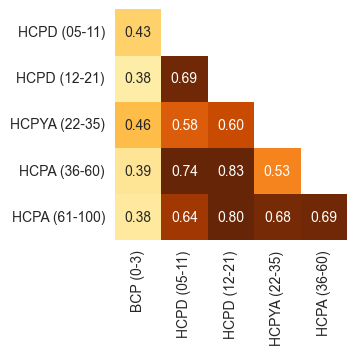

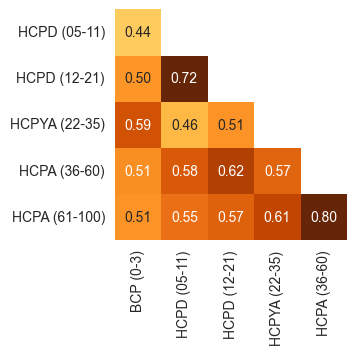

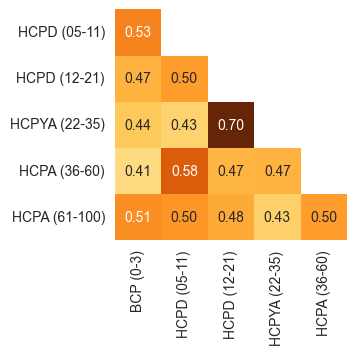

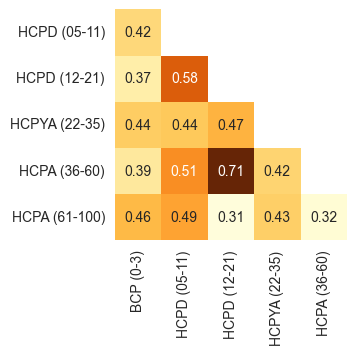

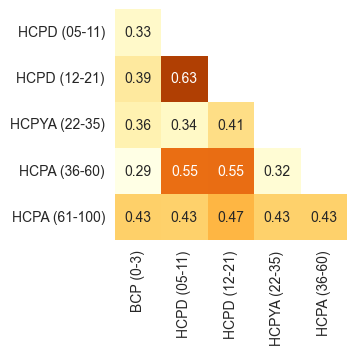

In [139]:
for cluster_n in range(2, 7):
    result = pd.read_csv(RESULTS_PATH / f'scores/JaccardIndex_K{cluster_n}.csv', index_col=0)
    result = result.iloc[1:, :-1]
    result = set_upper_tri_nan(result)
    print(f'When K = {cluster_n}, Mean Jaccard Index = {np.nanmean(result):.5f}')
    fig, ax = plt.subplots(figsize=(3, 3))
    sns.heatmap(result, annot=True, fmt='.2f', vmin=0.3, vmax=0.7,
                ax=ax, cbar=False, cmap='YlOrBr')
    ax.set_ylabel('')
    ax.set_xlabel('')
    fig.savefig(PLOTS_PATH / f'heatmap/JaccardIndex_{cluster_n}.svg', **PLOT_KWARGS_DICT)


# Adjusted Rand Index

In [140]:
for cluster_n in trange(2, 7):
    file_name_mapping = {k: data_folder / f'{v}_K{cluster_n}.nii.gz' for (k, v) in NAME_MAPPING_DICT.items()}
    result = []
    for name_1, name_2 in itertools.combinations(file_name_mapping.keys(), 2):
        file_1 = file_name_mapping[name_1]
        file_2 = file_name_mapping[name_2]

        data_1 = nib.load(file_1).get_fdata()
        data_2 = nib.load(file_2).get_fdata()

        mask_1 = data_1 > 0
        mask_2 = data_2 > 0
        shared_mask = mask_1 & mask_2

        data_1 = np.round(data_1)[shared_mask]
        data_2 = np.round(data_2)[shared_mask]

        score = adjusted_rand_score(data_1, data_2)
        result.append(dict(name_1=name_1, name_2=name_2, score=score))
        result.append(dict(name_1=name_2, name_2=name_1, score=score))
    result = pd.DataFrame(result)
    result = result.pivot(index='name_1', columns='name_2', values='score')
    result = result.loc[list(NAME_MAPPING_DICT.keys()), list(NAME_MAPPING_DICT.keys())]
    result.to_csv(RESULTS_PATH / f'scores/AdjustedRandIndex_K{cluster_n}.csv')

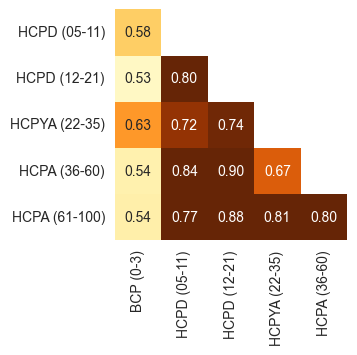

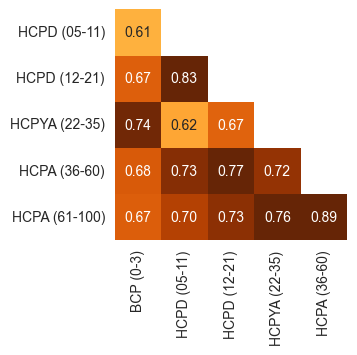

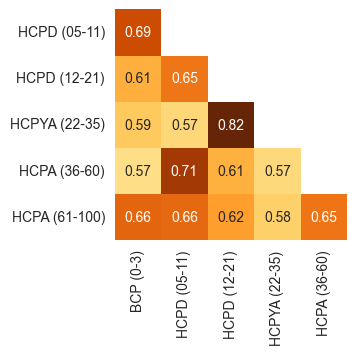

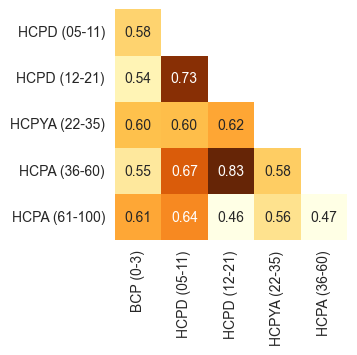

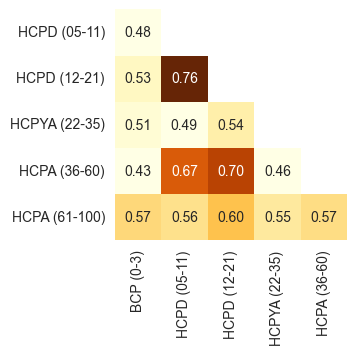

In [141]:
for cluster_n in range(2, 7):
    result = pd.read_csv(RESULTS_PATH / f'scores/Dice_K{cluster_n}.csv', index_col=0)
    result = result.iloc[1:, :-1]
    result = set_upper_tri_nan(result)
    print(f'When K = {cluster_n}, Mean Adjusted Rand Index = {np.nanmean(result):.5f}')
    fig, ax = plt.subplots(figsize=(3, 3))
    sns.heatmap(result, annot=True, fmt='.2f', vmin=0.5, vmax=0.75,
                ax=ax, cbar=False, cmap='YlOrBr')
    ax.set_ylabel('')
    ax.set_xlabel('')
    fig.savefig(PLOTS_PATH / f'heatmap/AdjustedRandIndex_{cluster_n}.svg', **PLOT_PARAMS)

# DICE

In [142]:
for cluster_n in trange(2, 7):
    file_name_mapping = {k: data_folder / f'{v}_K{cluster_n}.nii.gz' for (k, v) in NAME_MAPPING_DICT.items()}
    result = []
    for name_1, name_2 in itertools.combinations(file_name_mapping.keys(), 2):
        file_1 = file_name_mapping[name_1]
        file_2 = file_name_mapping[name_2]

        data_1 = nib.load(file_1).get_fdata()
        data_2 = nib.load(file_2).get_fdata()

        mask_1 = data_1 > 0
        mask_2 = data_2 > 0
        shared_mask = mask_1 & mask_2

        data_1 = np.round(data_1)[shared_mask]
        data_2 = np.round(data_2)[shared_mask]

        score = max_dice_score(data_1, data_2, cluster_n)
        result.append(dict(name_1=name_1, name_2=name_2, score=score))
        result.append(dict(name_1=name_2, name_2=name_1, score=score))
    result = pd.DataFrame(result)
    result = result.pivot(index='name_1', columns='name_2', values='score')
    result = result.loc[list(NAME_MAPPING_DICT.keys()), list(NAME_MAPPING_DICT.keys())]
    result.to_csv(RESULTS_PATH / f'scores/Dice_K{cluster_n}.csv')

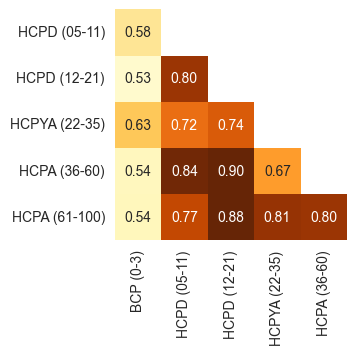

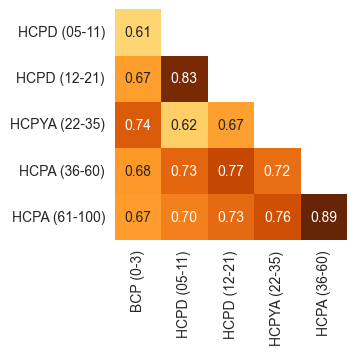

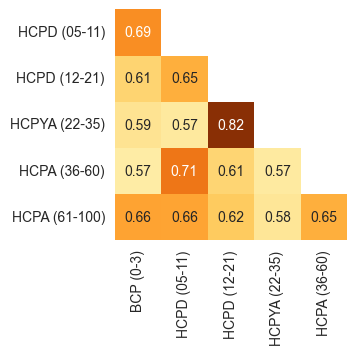

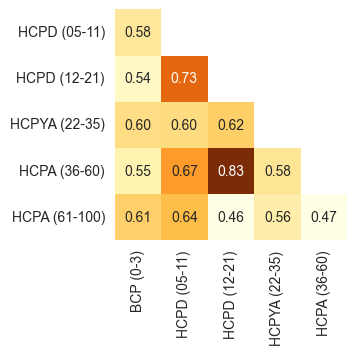

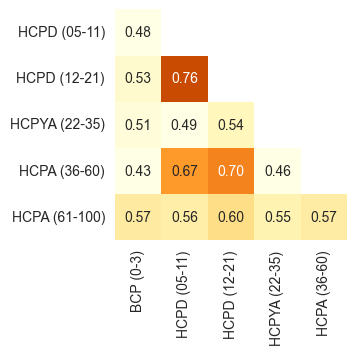

In [143]:
for cluster_n in range(2, 7):
    result = pd.read_csv(RESULTS_PATH / f'scores/Dice_K{cluster_n}.csv', index_col=0)
    result = result.iloc[1:, :-1]
    result = set_upper_tri_nan(result)
    print(f'When K = {cluster_n}, Mean Dice = {np.nanmean(result):.5f}')
    fig, ax = plt.subplots(figsize=(3, 3))
    sns.heatmap(result, annot=True, fmt='.2f', vmin=0.5, vmax=0.85,
                ax=ax, cbar=False, cmap='YlOrBr')
    ax.set_ylabel('')
    ax.set_xlabel('')
    fig.savefig(PLOTS_PATH / f'heatmap/Dice_{cluster_n}.svg', **PLOT_PARAMS)